In [98]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go

from sklearn.preprocessing import 

In [114]:
import numpy as np
import pandas as pd
from scipy import stats

def generate_extended_sales_data_normal(n_samples=1000):
    np.random.seed(42)

    # Customer Demographics - Normal distributions
    customer_ids = np.arange(10000, 10000 + n_samples)
    
    # Age: Normal distribution centered around 40, std=12, clipped between 18-75
    ages = np.clip(np.random.normal(40, 12, n_samples).astype(int), 18, 75)
    
    genders = np.random.choice(['Male', 'Female', 'Other'], size=n_samples, p=[0.48, 0.48, 0.04])
    
    # Income: Log-normal distribution for realistic income distribution
    incomes = np.clip(np.random.lognormal(mean=10.8, sigma=0.4, size=n_samples).astype(int), 20000, 200000)

    # Product Features - Normal distributions
    product_categories = np.random.choice(
        ['Electronics', 'Clothing', 'Home & Garden', 'Books', 'Sports', 'Beauty'], 
        size=n_samples
    )
    product_subcategories = [
        np.random.choice({
            'Electronics': ['Phones','Computers','Audio'],
            'Clothing': ['Men','Women','Kids'],
            'Home & Garden': ['Furniture','Kitchen','Decor'],
            'Books': ['Fiction','Non-Fiction','Children'],
            'Sports': ['Outdoor','Fitness','Team'],
            'Beauty': ['Skincare','Makeup','Hair']
        }[cat]) for cat in product_categories
    ]
    
    # Product prices: Log-normal distribution for realistic price distribution
    product_prices = np.clip(np.round(np.random.lognormal(mean=4.5, sigma=1.2, size=n_samples), 2), 5, 5000)
    
    # Cost prices: Normal distribution around 70% of product price
    cost_multiplier = np.clip(np.random.normal(0.7, 0.1, n_samples), 0.5, 0.9)
    cost_prices = np.round(product_prices * cost_multiplier, 2)
    
    # Quantities: Normal distribution centered around 3
    quantities = np.clip(np.random.normal(3, 1.5, n_samples).astype(int), 1, 10)

    # Store & Geography
    store_ids = np.random.choice([101, 102, 103, 104, 105], size=n_samples)
    regions = np.random.choice(['North','South','East','West'], size=n_samples)
    store_types = np.random.choice(['Online','Retail','Wholesale'], size=n_samples, p=[0.4,0.5,0.1])

    # Transaction Features
    start_date = pd.to_datetime('2025-01-01')
    # Normal distribution for transaction dates (centered around mid-year)
    date_offset = np.clip(np.random.normal(182, 60, n_samples).astype(int), 0, 364)
    transaction_dates = start_date + pd.to_timedelta(date_offset, unit='D')
    transaction_dates_series = pd.Series(transaction_dates)
    day_of_week = transaction_dates_series.dt.day_name()
    is_weekend = day_of_week.isin(['Saturday','Sunday'])

    # Promotions & Pricing - Normal distribution for discount rates
    base_discount = np.clip(np.random.normal(10, 8, n_samples), 0, 40)
    discount_rate = np.round(base_discount, 1)
    promo_flag = discount_rate > 0
    final_price = np.round(product_prices * (1 - discount_rate/100), 2)

    # Payment & Returns
    payment_methods = np.random.choice(['Credit Card','Debit Card','Cash','Digital Wallet'], size=n_samples)
    returned = np.random.choice([0,1], size=n_samples, p=[0.95,0.05])
    return_reason = [
        np.random.choice(['Defective','Changed Mind','Late Delivery','Other']) if ret else ''
        for ret in returned
    ]

    # Sales calculations
    revenue = np.round(final_price * quantities, 2)
    cost = np.round(cost_prices * quantities, 2)
    profit = np.round(revenue - cost, 2)

    # Customer satisfaction score - Normal distribution
    satisfaction_score = np.clip(np.round(np.random.normal(7.5, 1.5, n_samples), 1), 1, 10)

    # Assemble DataFrame
    df = pd.DataFrame({
        'CustomerID': customer_ids,
        'Age': ages,
        'Gender': genders,
        'Income': incomes,
        'Region': regions,
        'StoreID': store_ids,
        'StoreType': store_types,
        'TransactionDate': transaction_dates,
        'DayOfWeek': day_of_week.values,
        'IsWeekend': is_weekend.values,
        'Category': product_categories,
        'Subcategory': product_subcategories,
        'ListPrice': product_prices,
        'CostPrice': cost_prices,
        'DiscountRate': discount_rate,
        'PromoFlag': promo_flag,
        'FinalPrice': final_price,
        'Quantity': quantities,
        'PaymentMethod': payment_methods,
        'Returned': returned,
        'ReturnReason': return_reason,
        'Revenue': revenue,
        'Cost': cost,
        'Profit': profit,
        'SatisfactionScore': satisfaction_score
    })

    return df

# Generate the data
df= generate_extended_sales_data_normal()
print(df.head())


   CustomerID  Age  Gender  Income Region  StoreID  StoreType TransactionDate  \
0       10000   45    Male   43317   West      105     Retail      2025-08-29   
1       10001   38    Male   36284   West      104     Online      2025-07-16   
2       10002   47  Female   55696  South      104  Wholesale      2025-04-10   
3       10003   58  Female   83799  North      102     Retail      2025-05-04   
4       10004   37    Male   23154  North      102     Retail      2025-09-08   

   DayOfWeek  IsWeekend  ... PromoFlag FinalPrice  Quantity  PaymentMethod  \
0     Friday      False  ...      True     120.55         2    Credit Card   
1  Wednesday      False  ...      True      22.52         1     Debit Card   
2   Thursday      False  ...      True      47.76         5     Debit Card   
3     Sunday       True  ...      True     340.86         3    Credit Card   
4     Monday      False  ...      True      57.18         2     Debit Card   

   Returned   ReturnReason  Revenue    Cost 

In [115]:
df.to_excel("Sales_data1.xlsx",index=False)

In [101]:
df.describe()

,CustomerID,Age,Income,StoreID,TransactionDate,ListPrice,CostPrice,DiscountRate,FinalPrice,Quantity,Returned,Revenue,Cost,Profit,SatisfactionScore
count,1000.000000,1000.000000,1000.000000,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.00000
mean,10499.500000,39.848000,53180.706000,103.073000,2025-07-01 06:53:16.800000,180.554600,125.920830,10.061700,162.459250,2.558000,0.051000,435.082090,336.90816,98.173930,7.44840
min,10000.000000,18.000000,20000.000000,101.000000,2025-01-01 00:00:00,5.000000,2.670000,0.000000,3.790000,1.000000,0.000000,4.140000,3.49000,-173.100000,3.30000
25%,10249.750000,32.000000,37908.000000,102.000000,2025-05-22 00:00:00,41.195000,28.817500,4.300000,36.762500,1.000000,0.000000,70.570000,54.66000,9.840000,6.40000
50%,10499.500000,40.000000,49156.500000,103.000000,2025-06-30 00:00:00,84.110000,60.045000,9.700000,76.030000,2.000000,0.000000,172.575000,133.79000,34.290000,7.40000
75%,10749.250000,47.000000,63984.500000,104.000000,2025-08-11 00:00:00,203.065000,134.137500,14.900000,187.990000,3.000000,0.000000,438.965000,348.47250,88.642500,8.50000
max,10999.000000,75.000000,171974.000000,105.000000,2025-12-31 00:00:00,2496.560000,1985.610000,33.300000,2451.620000,7.000000,1.000000,8596.150000,7093.50000,3105.000000,10.00000
std,288.819436,11.447967,21482.456844,1.421862,NaN,265.848644,190.264636,7.187854,244.245781,1.353687,0.220108,767.540136,593.66916,211.975017,1.45009


In [102]:
df.head()

,CustomerID,Age,Gender,Income,Region,StoreID,StoreType,TransactionDate,DayOfWeek,IsWeekend,...,PromoFlag,FinalPrice,Quantity,PaymentMethod,Returned,ReturnReason,Revenue,Cost,Profit,SatisfactionScore
0,10000,45,Male,43317,West,105,Retail,2025-08-29,Friday,False,...,True,120.55,2,Credit Card,1,Late Delivery,241.10,181.42,59.68,7.3
1,10001,38,Male,36284,West,104,Online,2025-07-16,Wednesday,False,...,True,22.52,1,Debit Card,0,,22.52,20.80,1.72,5.9
2,10002,47,Female,55696,South,104,Wholesale,2025-04-10,Thursday,False,...,True,47.76,5,Debit Card,0,,238.80,163.70,75.10,10.0
3,10003,58,Female,83799,North,102,Retail,2025-05-04,Sunday,True,...,True,340.86,3,Credit Card,0,,1022.58,728.79,293.79,9.4
4,10004,37,Male,23154,North,102,Retail,2025-09-08,Monday,False,...,True,57.18,2,Debit Card,0,,114.36,79.50,34.86,6.5


In [103]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Income', 'Region', 'StoreID',
       'StoreType', 'TransactionDate', 'DayOfWeek', 'IsWeekend', 'Category',
       'Subcategory', 'ListPrice', 'CostPrice', 'DiscountRate', 'PromoFlag',
       'FinalPrice', 'Quantity', 'PaymentMethod', 'Returned', 'ReturnReason',
       'Revenue', 'Cost', 'Profit', 'SatisfactionScore'],
      dtype='object')

In [104]:
features = ['Age','Gender','Income','Region','StoreType','IsWeekend','Subcategory','DiscountRate','ListPrice','Quantity','Returned']
target = 'Revenue'
numeric_columns = [col for col in df[features].columns if df[col].dtype in ['int64','int32','bool','float64','float32']]
categorical_columns = [col for col in df[features].columns if col not in numeric_columns]
print(f"{len(numeric_columns)} numeric_columns:{numeric_columns}\n{len(categorical_columns)} categorical_columns: {categorical_columns}\nTotal {len(numeric_columns+categorical_columns)} columns")

7 numeric_columns:['Age', 'Income', 'IsWeekend', 'DiscountRate', 'ListPrice', 'Quantity', 'Returned']
4 categorical_columns: ['Gender', 'Region', 'StoreType', 'Subcategory']
Total 11 columns


In [105]:
df[features]

,Age,Gender,Income,Region,StoreType,IsWeekend,Subcategory,DiscountRate,ListPrice,Quantity,Returned
0,45,Male,43317,West,Retail,False,Children,6.3,128.65,2,1
1,38,Male,36284,West,Online,False,Audio,8.1,24.50,1,0
2,47,Female,55696,South,Wholesale,False,Non-Fiction,9.7,52.89,5,0
3,58,Female,83799,North,Retail,True,Team,8.3,371.71,3,0
4,37,Male,23154,North,Retail,False,Team,11.3,64.47,2,0
...,...,...,...,...,...,...,...,...,...,...,...
995,36,Male,37801,East,Wholesale,False,Skincare,6.8,134.15,2,0
996,61,Male,30294,East,Retail,True,Computers,7.6,301.24,1,0
997,47,Female,32311,East,Retail,False,Women,11.5,419.29,2,0
998,33,Male,40340,West,Retail,True,Children,4.1,57.17,1,0


In [106]:
df[numeric_columns]

,Age,Income,IsWeekend,DiscountRate,ListPrice,Quantity,Returned
0,45,43317,False,6.3,128.65,2,1
1,38,36284,False,8.1,24.50,1,0
2,47,55696,False,9.7,52.89,5,0
3,58,83799,True,8.3,371.71,3,0
4,37,23154,False,11.3,64.47,2,0
...,...,...,...,...,...,...,...
995,36,37801,False,6.8,134.15,2,0
996,61,30294,True,7.6,301.24,1,0
997,47,32311,False,11.5,419.29,2,0
998,33,40340,True,4.1,57.17,1,0


In [107]:
df[categorical_columns]

,Gender,Region,StoreType,Subcategory
0,Male,West,Retail,Children
1,Male,West,Online,Audio
2,Female,South,Wholesale,Non-Fiction
3,Female,North,Retail,Team
4,Male,North,Retail,Team
...,...,...,...,...
995,Male,East,Wholesale,Skincare
996,Male,East,Retail,Computers
997,Female,East,Retail,Women
998,Male,West,Retail,Children


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   CustomerID         1000 non-null   int64         
 1   Age                1000 non-null   int64         
 2   Gender             1000 non-null   object        
 3   Income             1000 non-null   int64         
 4   Region             1000 non-null   object        
 5   StoreID            1000 non-null   int64         
 6   StoreType          1000 non-null   object        
 7   TransactionDate    1000 non-null   datetime64[ns]
 8   DayOfWeek          1000 non-null   object        
 9   IsWeekend          1000 non-null   bool          
 10  Category           1000 non-null   object        
 11  Subcategory        1000 non-null   object        
 12  ListPrice          1000 non-null   float64       
 13  CostPrice          1000 non-null   float64       
 14  DiscountR

In [109]:
for i in categorical_columns:
    uniques = df[i].unique().astype('str')
    length = len(uniques)
    print(f"{length} {i} : {uniques}")

3 Gender : ['Male' 'Female' 'Other']
4 Region : ['West' 'South' 'North' 'East']
3 StoreType : ['Retail' 'Online' 'Wholesale']
18 Subcategory : ['Children' 'Audio' 'Non-Fiction' 'Team' 'Men' 'Skincare' 'Women' 'Makeup'
 'Hair' 'Kids' 'Furniture' 'Fiction' 'Outdoor' 'Kitchen' 'Phones'
 'Computers' 'Decor' 'Fitness']


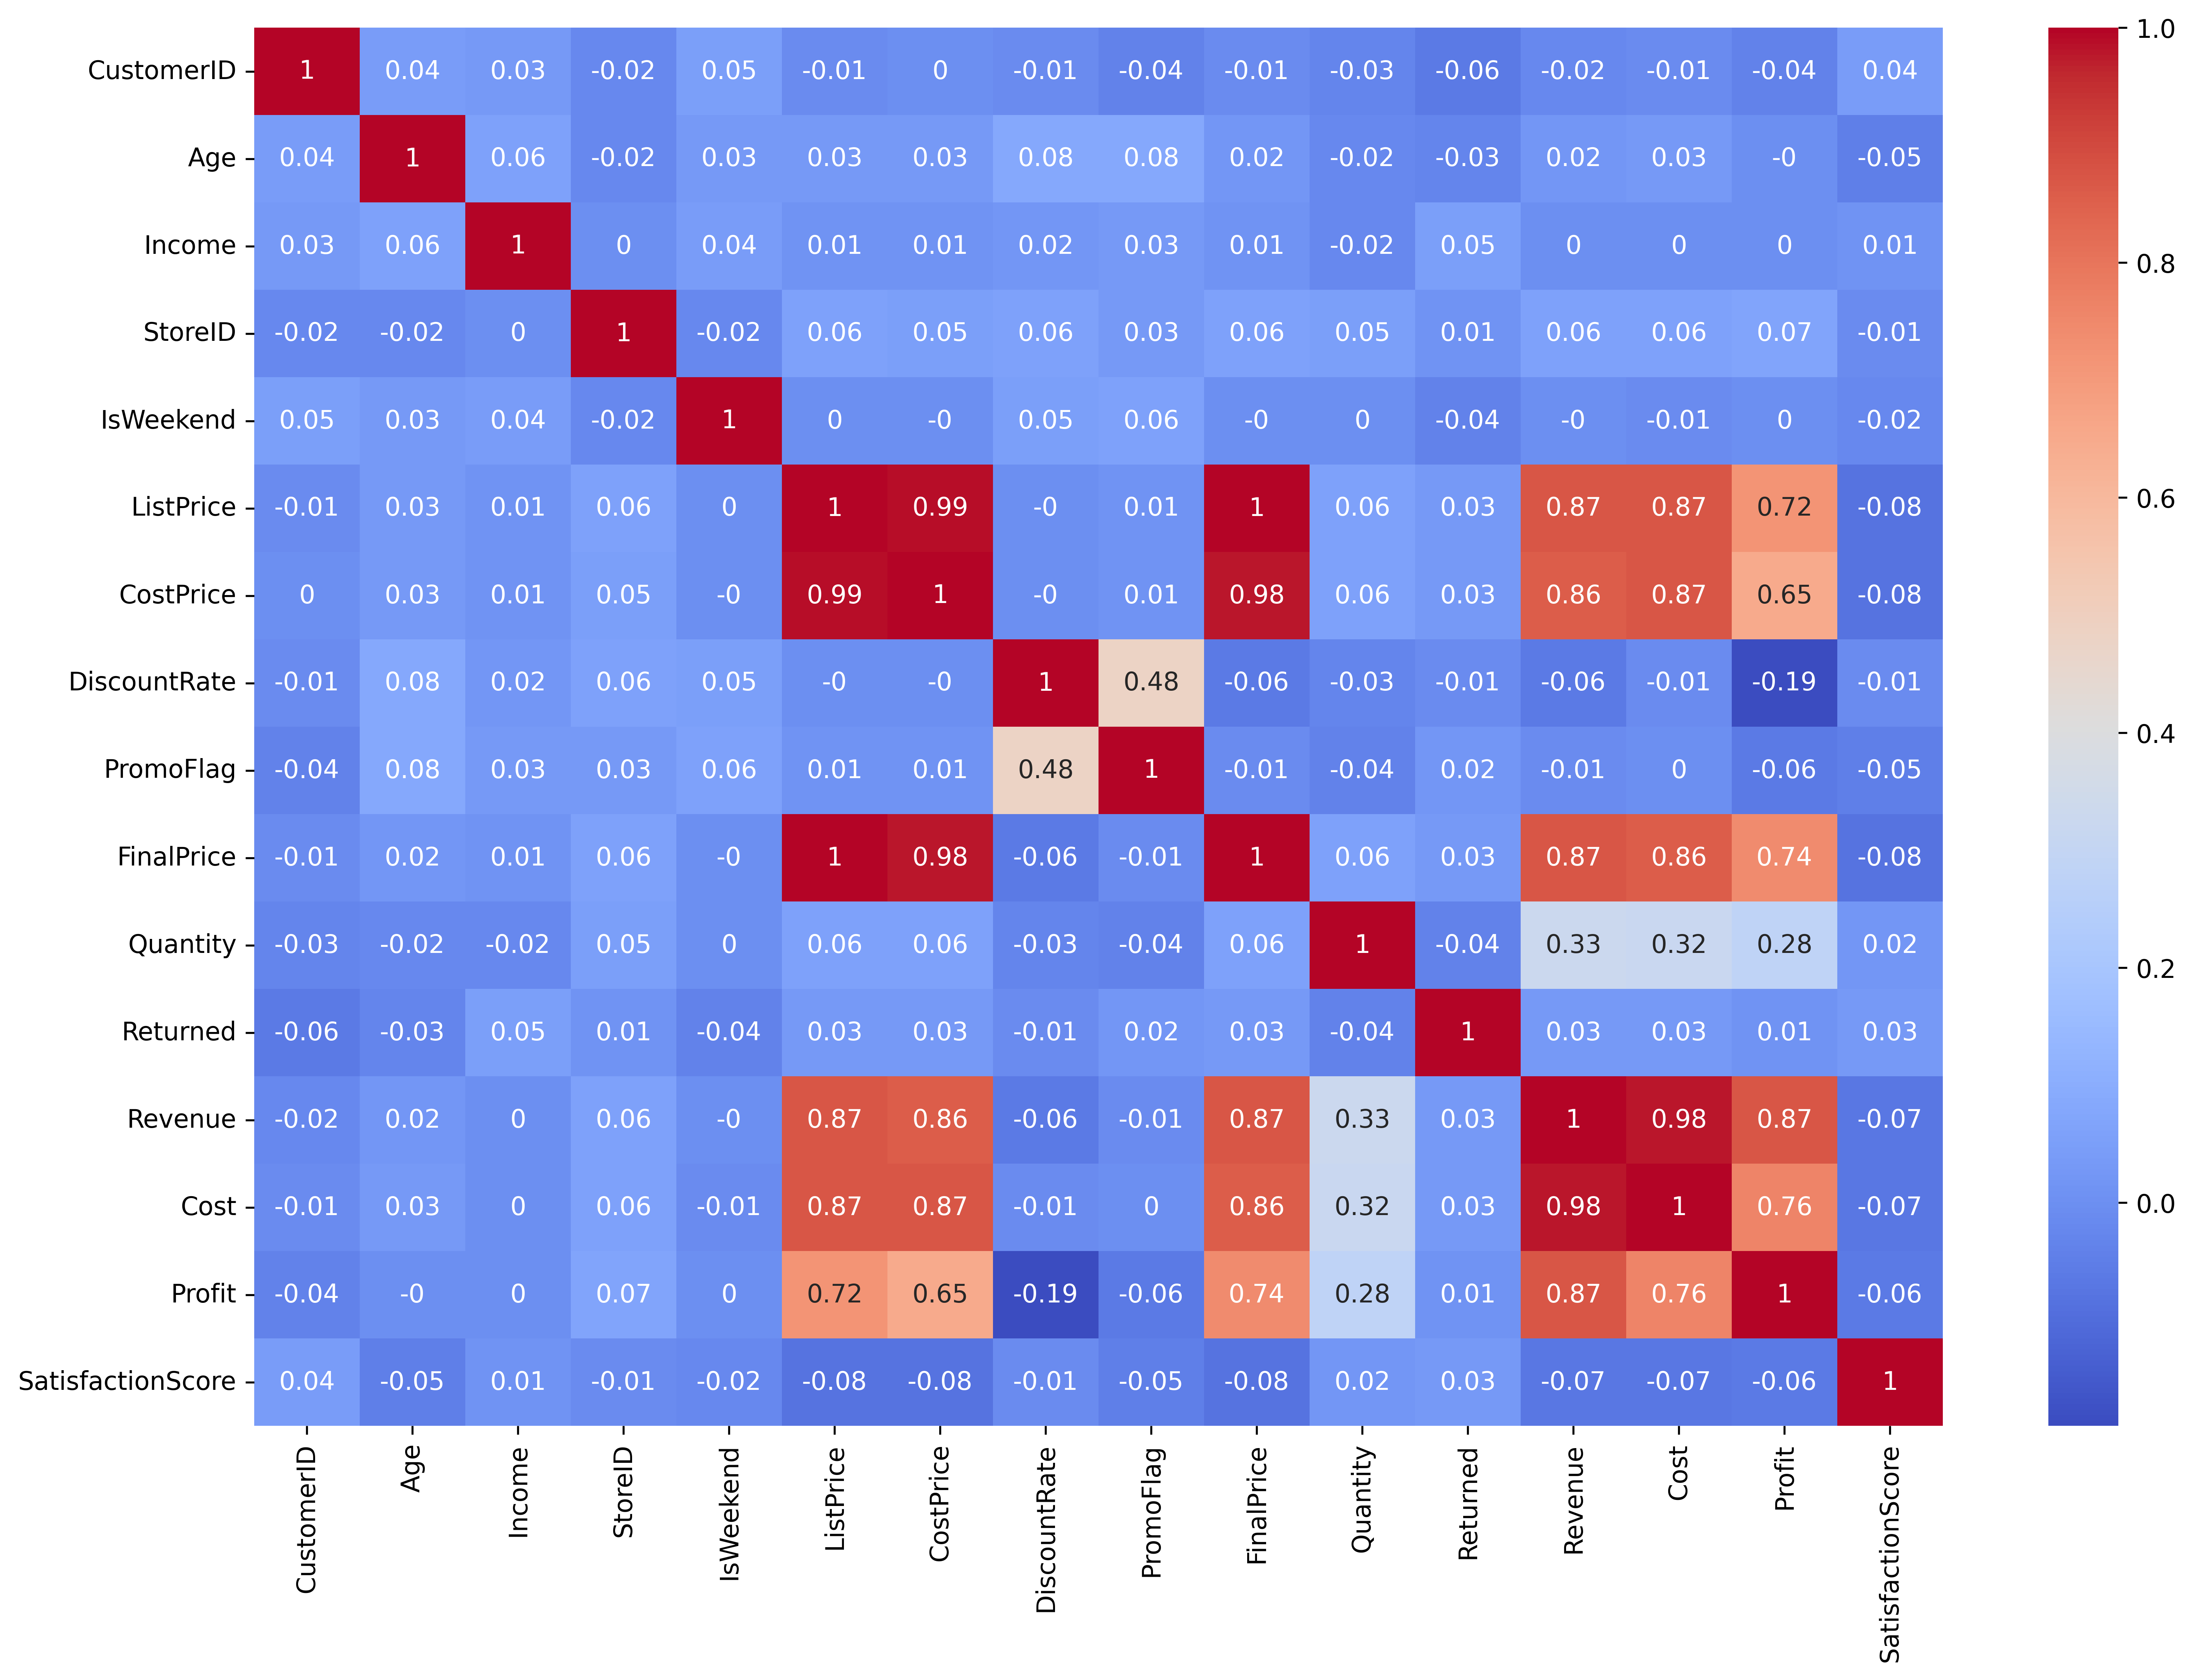

In [110]:
plt.figure(figsize=(15,10),dpi=480)
sns.heatmap(df.corr(numeric_only=True).round(2),annot=True,cmap='coolwarm')
plt.show()

In [111]:
df[numeric_columns]

,Age,Income,IsWeekend,DiscountRate,ListPrice,Quantity,Returned
0,45,43317,False,6.3,128.65,2,1
1,38,36284,False,8.1,24.50,1,0
2,47,55696,False,9.7,52.89,5,0
3,58,83799,True,8.3,371.71,3,0
4,37,23154,False,11.3,64.47,2,0
...,...,...,...,...,...,...,...
995,36,37801,False,6.8,134.15,2,0
996,61,30294,True,7.6,301.24,1,0
997,47,32311,False,11.5,419.29,2,0
998,33,40340,True,4.1,57.17,1,0


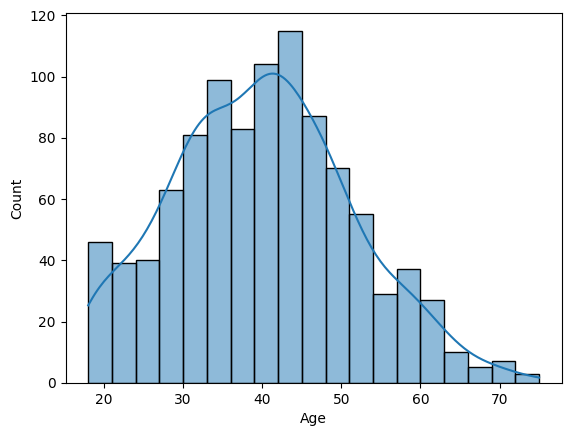

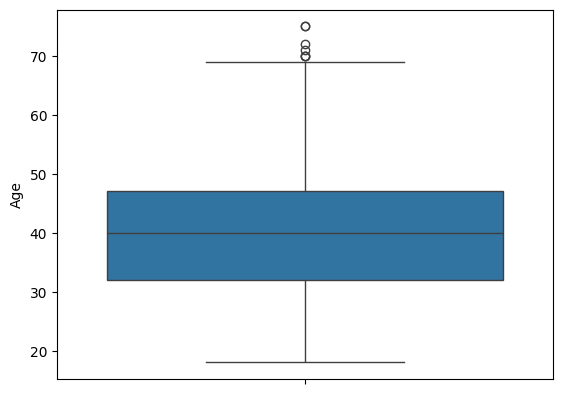

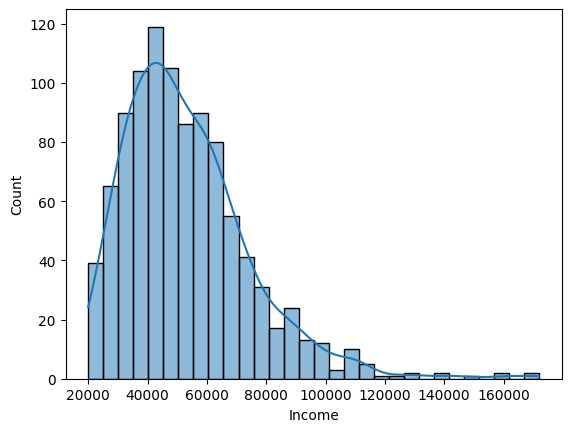

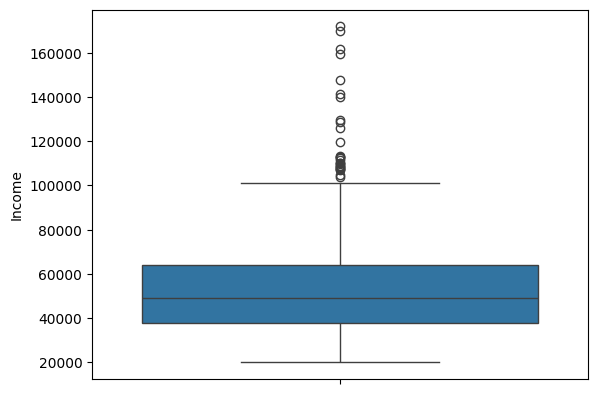

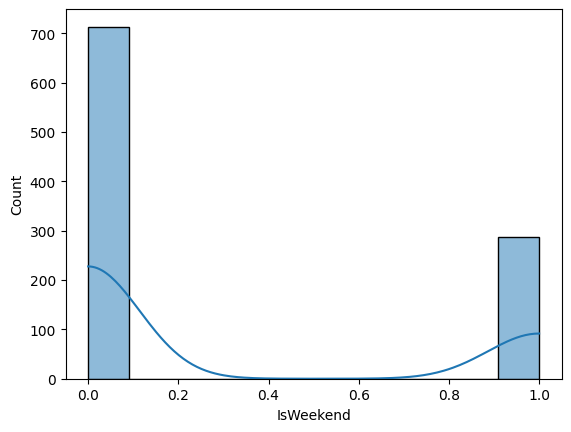

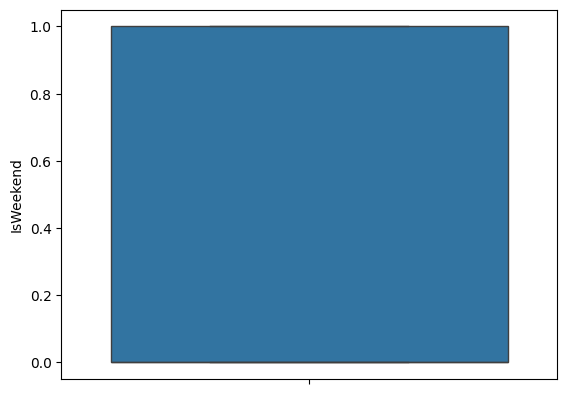

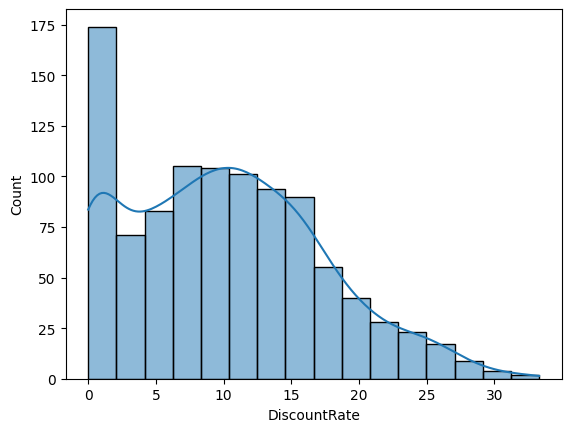

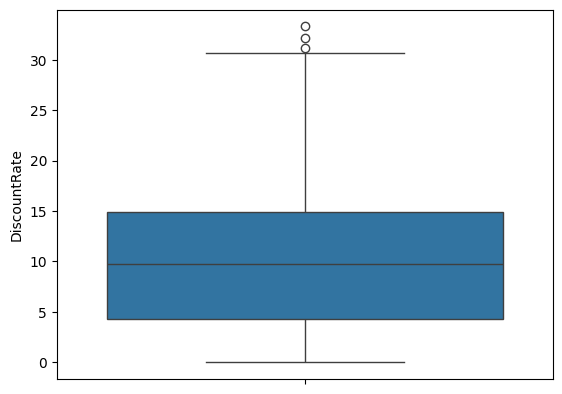

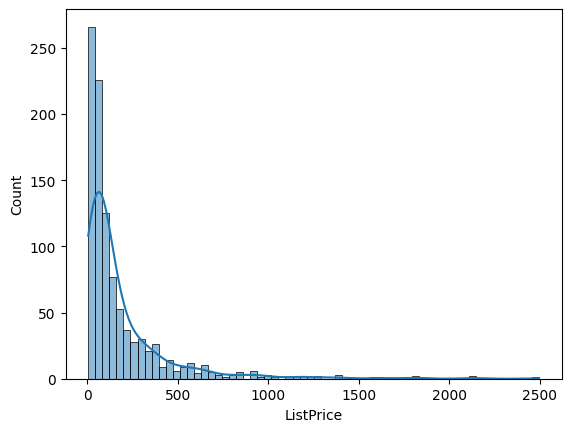

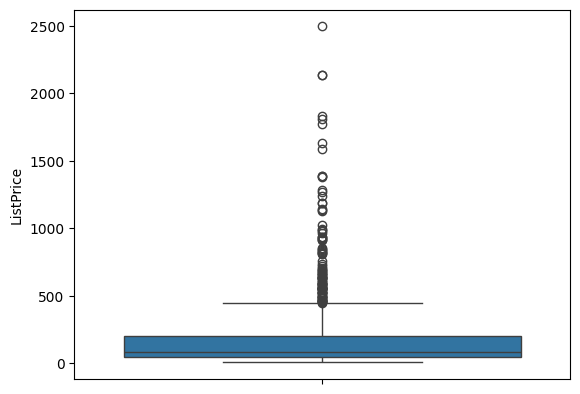

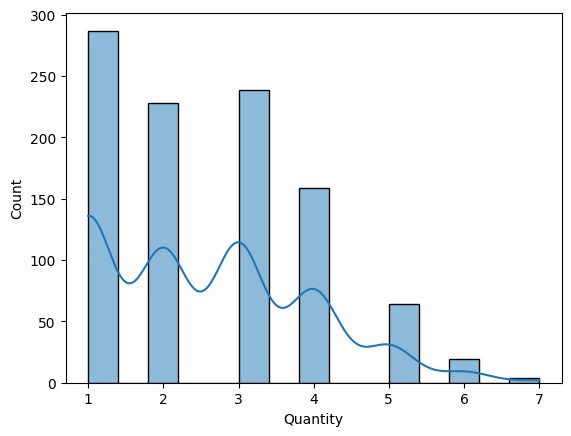

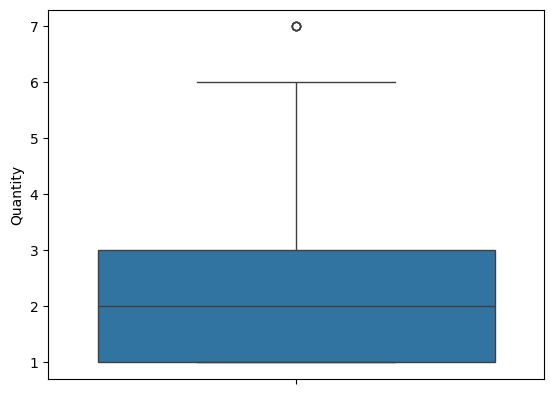

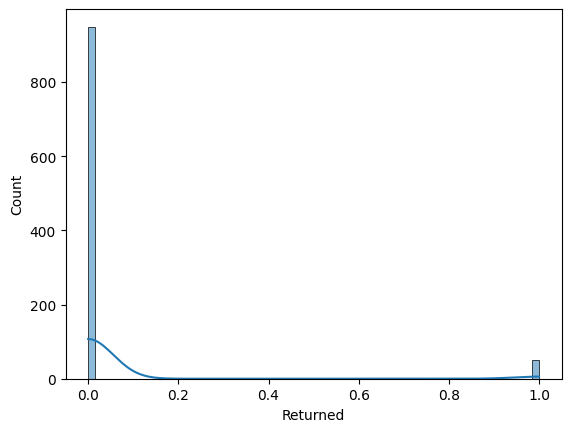

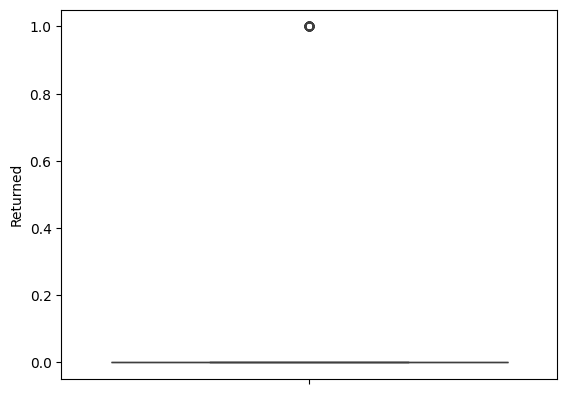

In [112]:
for i in numeric_columns:
    sns.histplot(df[i],kde=True)
    plt.show()
    sns.boxplot(df[i])
    plt.show()